<a href="https://colab.research.google.com/github/litlig/notebooks/blob/main/2d_diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diffusion model explained with 2-D examples

### Problem framing

All images are sampled from a probability distribution in a high-dim space. To generate a image, we can directly model the prob. distribution. Diffusion models follows a differnt path: it models the trajectory of transforming a sample generated from a known distribution to the unknown image space.

To illustrate, we say that the image have two pixels in a continous grey scale, then we can plot the distribution of all images in a 2-dim chart.

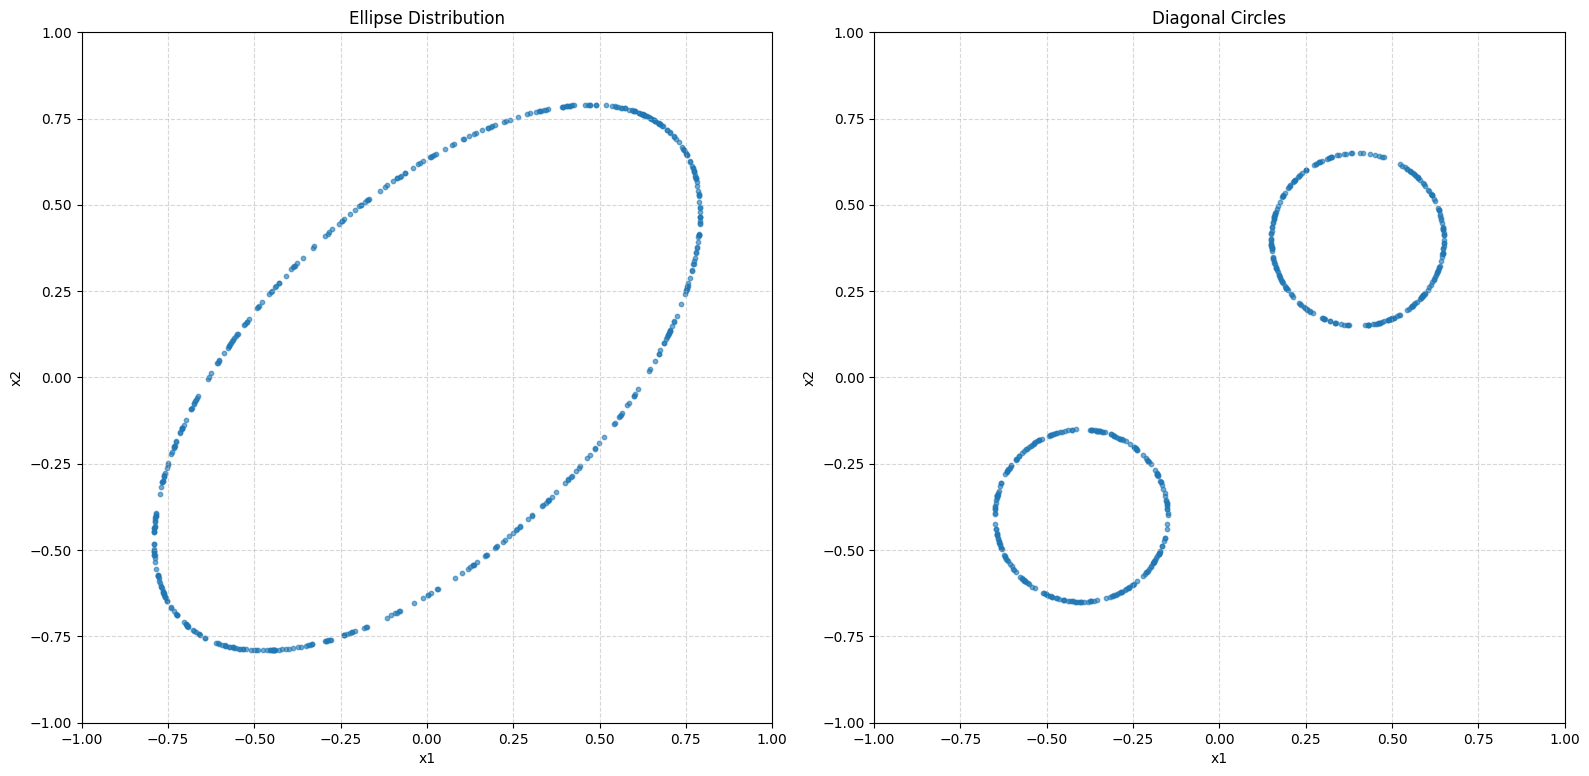

In [3]:
# @title 2D distribution examples
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, Tuple

def ellipse_distribution(batch_size: int = 1) -> np.ndarray:
  t = 2 * np.pi * np.random.rand(batch_size)
  theta_rad = np.pi / 4

  # Parametric equations for the ellipse
  x1 = 1.0 * np.cos(t)
  x2 = 0.5 * np.sin(t)

  # Apply rotation
  x1_rot = x1 * np.cos(theta_rad) - x2 * np.sin(theta_rad)
  x2_rot = x1 * np.sin(theta_rad) + x2 * np.cos(theta_rad)

  # Keep it zero-centered to match noise distribution
  return np.stack([x1_rot, x2_rot], axis=-1)

def diagonal_circles_distribution(batch_size: int = 1) -> np.ndarray:
  # Create two circles
  n_per_circle = batch_size // 2
  t = 2 * np.pi * np.random.rand(batch_size)
  r = 0.25

  centers = np.zeros((batch_size, 2))
  centers[:n_per_circle, :] = -0.4
  centers[n_per_circle:, :] = 0.4

  x1 = centers[:, 0] + r * np.cos(t)
  x2 = centers[:, 1] + r * np.sin(t)

  return np.stack([x1, x2], axis=-1)

def plot_side_by_side(dist1_fn, dist2_fn):
  fig, axes = plt.subplots(1, 2, figsize=(16, 8))
  for ax, fn, title in zip(axes, [dist1_fn, dist2_fn], ['Ellipse Distribution', 'Diagonal Circles']):
    samples = fn(500)
    ax.scatter(samples[:, 0], samples[:, 1], alpha=0.6, s=10)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title(title)
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_aspect('equal')
  plt.tight_layout()
  plt.show()

plot_side_by_side(ellipse_distribution, diagonal_circles_distribution)

### Flow Matching
Imagine we start with a sample of pure white noise $x_0$ and we want to reach a specific data point $z$ (the 'image') at time $t=1$. We can define a **probability path** $x_t$ that connects noise to data:

$$x_t = a_tx_0 + b_tz$$

Where $a_t$ and $b_t$ are **noise schedulers** with the following boundary conditions:
* At $t=0$: $a_0=1, b_0=0$ (Pure noise)
* At $t=1$: $a_1=0, b_1=1$ (Pure data)

#### Flow Matching Objective
The goal is to learn a **vector field** $v(x_t, t)$ that describes the 'velocity' or direction of this trajectory. The conditional vector field (the velocity given a fixed target $z$) is:

$$v_t(x|z) = \dot{a_t}x_0 + \dot{b_t}z$$

To get the un-conditional vector field, or average the vector field at a given point $x_t$ for all possible $z$, we need to take the integral over the distribution of z given x_t. We can further transform the math form using bayes theory, but the final formula is still not tractable. However, it's proved that: minimizing the mean squared error against the **conditional** vector field $v_t(x|z)$ is equivalent to minimizing it against the **marginal** vector field. We train a neural network $f(x_t, t, \theta)$ using the following objective:

$$\min_{\theta} \mathbb{E}_{t, q(z), p(x_0)} \| f(x_t, t, \theta) - v_t(x_t|z) \|^2$$

By regressing against the simple-to-calculate $v_t(x|z)$, the model implicitly learns to follow the complex marginal flow of the data distribution.

In [4]:
# @title Train a nn to estimate the vector field
import torch
import torch.nn as nn
import torch.nn.functional as F

def get_batch(dist_fn, batch_size):
  z = torch.from_numpy(dist_fn(batch_size)).float()
  x0 = torch.randn(batch_size, 2)
  t = torch.rand(batch_size, 1)
  xt = (1-t) * x0 + t * z
  vf = z - x0
  return xt, t, vf

def loss_fn(dist_fn, model, batch_size):
  xt, t, vf = get_batch(dist_fn, batch_size)
  model_input = torch.cat([xt, t], dim=-1)
  vf_pred = model(model_input)
  return F.mse_loss(vf_pred, vf)

def train(dist_fn, num_epochs=10000, batch_size=256, lr=0.001, plot_loss=True):
  # Increased capacity: wider and deeper to handle multi-modality
  model = nn.Sequential(
    nn.Linear(3, 256),
    nn.SiLU(),
    nn.Linear(256, 256),
    nn.SiLU(),
    nn.Linear(256, 256),
    nn.SiLU(),
    nn.Linear(256, 2),
  )

  optimizer = torch.optim.Adam(model.parameters(), lr)
  losses = []

  for epoch in range(num_epochs):
    optimizer.zero_grad()
    loss = loss_fn(dist_fn, model, batch_size)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch % 1000 == 0:
      print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

  if plot_loss:
    plt.figure(figsize=(8, 4))
    plt.plot(losses)
    plt.yscale('log')
    plt.title('Training Loss')
    plt.show()

  return model

print("Training for ellipse example...")
elip_model = train(ellipse_distribution, plot_loss=False)
print("Training for diagonal circles example...")
circ_model = train(diagonal_circles_distribution, plot_loss=False)

Training for ellipse example...
Epoch 0, Loss: 1.221673
Epoch 1000, Loss: 0.656360
Epoch 2000, Loss: 0.723843
Epoch 3000, Loss: 0.727034
Epoch 4000, Loss: 0.684411
Epoch 5000, Loss: 0.663060
Epoch 6000, Loss: 0.619958
Epoch 7000, Loss: 0.670588
Epoch 8000, Loss: 0.704869
Epoch 9000, Loss: 0.736802
Training for diagonal circles example...
Epoch 0, Loss: 1.221231
Epoch 1000, Loss: 0.557423
Epoch 2000, Loss: 0.575519
Epoch 3000, Loss: 0.545651
Epoch 4000, Loss: 0.579053
Epoch 5000, Loss: 0.617850
Epoch 6000, Loss: 0.522372
Epoch 7000, Loss: 0.553996
Epoch 8000, Loss: 0.524899
Epoch 9000, Loss: 0.440569


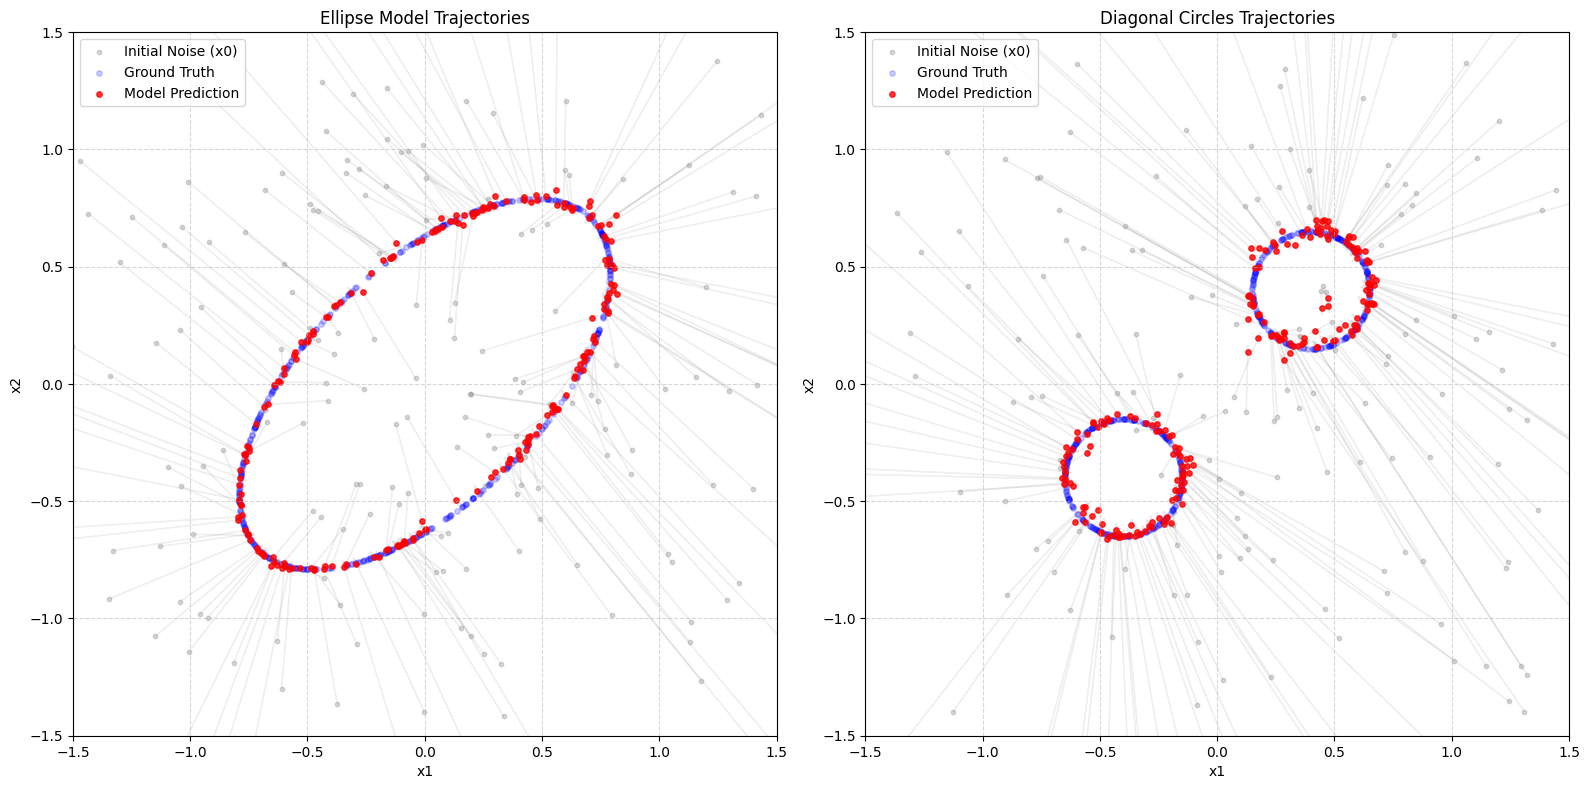

In [5]:
# @title sampling using trained nn
def sample_with_noise(model, nsample, steps=100):
  model.eval()
  with torch.no_grad():
    x_0 = torch.randn(nsample, 2)
    x = x_0.clone()
    dt = 1.0 / steps
    for step in range(steps):
      t = (step / steps) * torch.ones(nsample, 1)
      model_input = torch.cat([x, t], dim=-1)
      vf = model(model_input)
      x = x + vf * dt
  return x_0.cpu().numpy(), x.cpu().numpy()

def compare_all_results(elip_model, circ_model, n_samples=200): # Reduced n_samples for arrow clarity
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Plot Ellipse Results
    gt_elip = ellipse_distribution(500)
    noise_elip, pred_elip = sample_with_noise(elip_model, n_samples)

    # Draw arrows
    for i in range(n_samples):
        axes[0].arrow(noise_elip[i, 0], noise_elip[i, 1],
                      pred_elip[i, 0] - noise_elip[i, 0],
                      pred_elip[i, 1] - noise_elip[i, 1],
                      color='grey', alpha=0.1, head_width=0.02)

    axes[0].scatter(noise_elip[:, 0], noise_elip[:, 1], alpha=0.3, s=10, label='Initial Noise (x0)', color='grey')
    axes[0].scatter(gt_elip[:, 0], gt_elip[:, 1], alpha=0.2, s=15, label='Ground Truth', color='blue')
    axes[0].scatter(pred_elip[:, 0], pred_elip[:, 1], alpha=0.8, s=15, label='Model Prediction', color='red')
    axes[0].set_title('Ellipse Model Trajectories')
    axes[0].legend()

    # Plot Circle Results
    gt_circ = diagonal_circles_distribution(500)
    noise_circ, pred_circ = sample_with_noise(circ_model, n_samples)

    # Draw arrows
    for i in range(n_samples):
        axes[1].arrow(noise_circ[i, 0], noise_circ[i, 1],
                      pred_circ[i, 0] - noise_circ[i, 0],
                      pred_circ[i, 1] - noise_circ[i, 1],
                      color='grey', alpha=0.1, head_width=0.02)

    axes[1].scatter(noise_circ[:, 0], noise_circ[:, 1], alpha=0.3, s=10, label='Initial Noise (x0)', color='grey')
    axes[1].scatter(gt_circ[:, 0], gt_circ[:, 1], alpha=0.2, s=15, label='Ground Truth', color='blue')
    axes[1].scatter(pred_circ[:, 0], pred_circ[:, 1], alpha=0.8, s=15, label='Model Prediction', color='red')
    axes[1].set_title('Diagonal Circles Trajectories')
    axes[1].legend()

    for ax in axes:
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        ax.set_xlim([-1.5, 1.5])
        ax.set_ylim([-1.5, 1.5])
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()

compare_all_results(elip_model, circ_model)

#### Flow matching unpacked

Flow matching is moving the noise points towards the closest image points in terms of Euclidean distance. Why is it so? The training sample we used are retunred by get_batch fn:
```
def get_batch(dist_fn, batch_size):
  z = torch.from_numpy(dist_fn(batch_size)).float()
  x0 = torch.randn(batch_size, 2)
  t = torch.rand(batch_size, 1)
  xt = (1-t) * x0 + t * z
  vf = z - x0
  return xt, t, vf
```
We randomly pick a image from the image collection, then $x_0$ is sampled from a Gaussian $N(0, I)$, and t is sampled from unifrom distribution from 0 to 1. Why would $x_0$ converges to the closest z, after training on a dataset that shows no such bias or tendency?

The estimated vector field at $x_t$ and t is the average vector field for all possible z. At $t=0$, $x_t$ is pure noise and $p(z|x_t)$ are the same as the prior, so $x_t$ is drawn to the center of probabilty mess. When $t>0$,  $x_t$ starts to encode which z is more possile, and $p(z|x_t)$ are larger for z that's closer, so $x_t$ is drawn closer to these points.


### Diffusion models



In [12]:
# use trained vector field to sample

def sample_sde(model, nsample, steps=100, sigma = 1.0):
  model.eval()
  with torch.no_grad():
    x_0 = torch.randn(nsample, 2)
    x = x_0.clone()
    dt = 1.0 / steps
    for step in range(steps):
      t = (step / steps) * torch.ones(nsample, 1)
      model_input = torch.cat([x, t], dim=-1)
      vf = model(model_input)
      # Avoid division by zero at t=1, though loop typically ends before
      sf = (t * vf - x) / torch.clamp(1 - t, min=1e-5)
      x = x + (vf + sf * sigma * (dt**2)/2)* dt + sigma * torch.randn_like(x) * np.sqrt(dt)
  return x_0.cpu().numpy(), x.cpu().numpy()

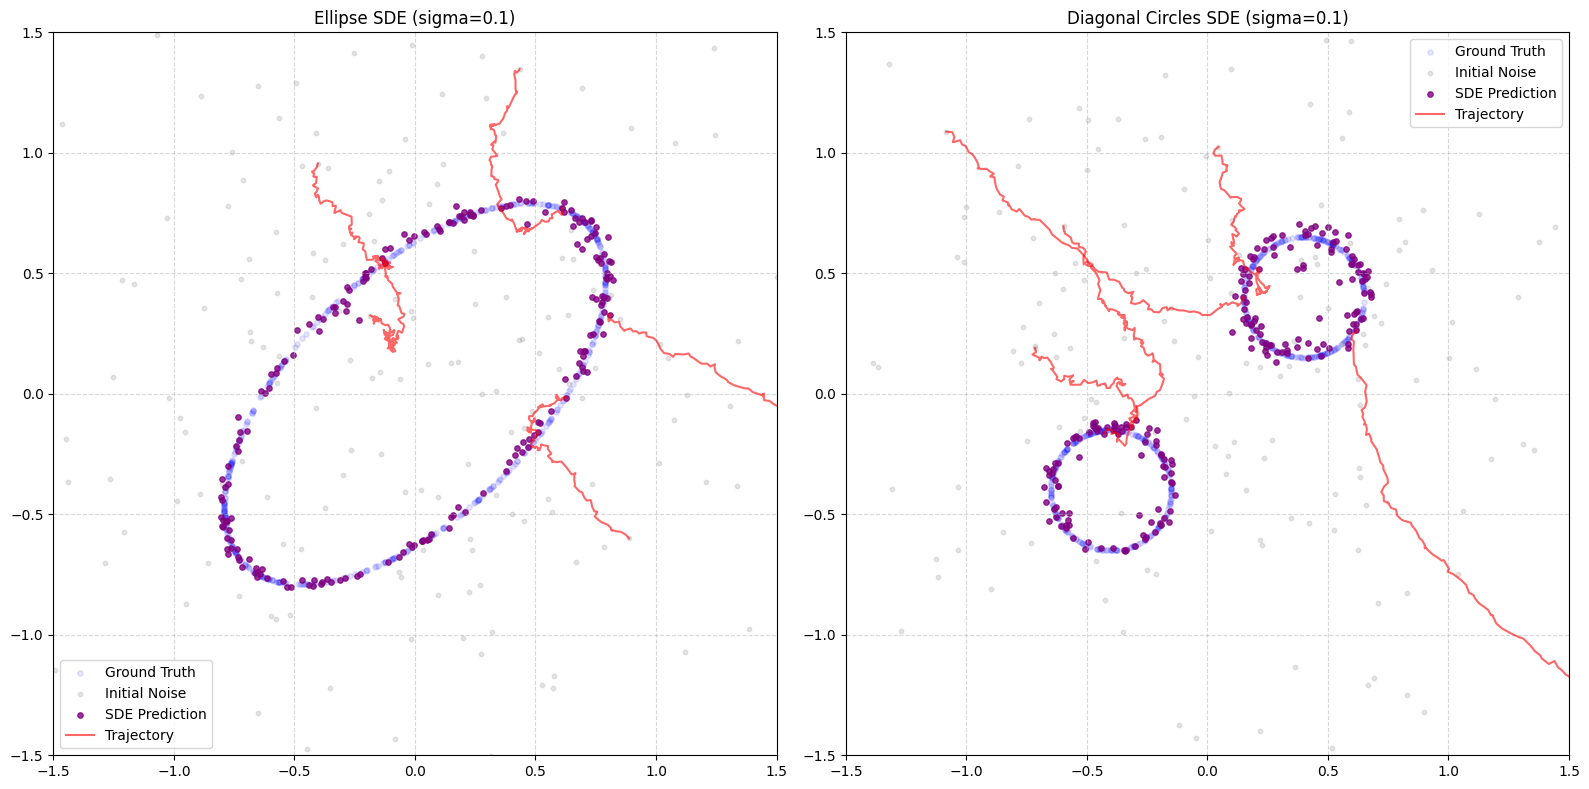

In [13]:
def sample_sde_with_trajectories(model, nsample, steps=100, sigma=1.0):
    model.eval()
    with torch.no_grad():
        x_0 = torch.randn(nsample, 2)
        x = x_0.clone()
        traj = [x.cpu().numpy().copy()]
        dt = 1.0 / steps
        for step in range(steps):
            t_val = step / steps
            t = t_val * torch.ones(nsample, 1)
            model_input = torch.cat([x, t], dim=-1)
            vf = model(model_input)
            sf = (t * vf - x) / torch.clamp(1 - t, min=1e-5)
            x = x + (vf + sf * sigma * (dt**2)/2)* dt + sigma * torch.randn_like(x) * np.sqrt(dt)
            traj.append(x.cpu().numpy().copy())
    return x_0.cpu().numpy(), x.cpu().numpy(), np.array(traj)

def compare_sde_results_with_traj(elip_model, circ_model, n_samples=200, sigma=0.1, n_traj=5):
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    for i, (model, dist_fn, title) in enumerate([(elip_model, ellipse_distribution, 'Ellipse'), (circ_model, diagonal_circles_distribution, 'Diagonal Circles')]):
        gt = dist_fn(500)
        noise, pred, trajs = sample_sde_with_trajectories(model, n_samples, sigma=sigma)

        # Plot ground truth and endpoints
        axes[i].scatter(gt[:, 0], gt[:, 1], alpha=0.1, s=15, label='Ground Truth', color='blue')
        axes[i].scatter(noise[:, 0], noise[:, 1], alpha=0.2, s=10, label='Initial Noise', color='grey')
        axes[i].scatter(pred[:, 0], pred[:, 1], alpha=0.8, s=15, label='SDE Prediction', color='purple')

        # Plot a few specific trajectories
        for j in range(n_traj):
            axes[i].plot(trajs[:, j, 0], trajs[:, j, 1], color='red', alpha=0.6, linewidth=1.5, label='Trajectory' if j==0 else "")

        axes[i].set_title(f'{title} SDE (sigma={sigma})')
        axes[i].set_xlim([-1.5, 1.5]); axes[i].set_ylim([-1.5, 1.5])
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes[i].set_aspect('equal')
        axes[i].legend()

    plt.tight_layout()
    plt.show()

compare_sde_results_with_traj(elip_model, circ_model, sigma=0.1)